## Cargar corpus

In [7]:
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Configuración de gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
df_raw = pd.read_csv("data/rotten_tomatoes_movies.csv")
df_raw

,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning T...,"Always trouble-prone, the life of teenager Per...",Though it may seem like just another Harry Pot...,PG,"Action & Adventure, Comedy, Drama, Science Fic...",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Da...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (...,Nicole Holofcener's newest might seem slight i...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, R...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter...",Blake Edwards' bawdy comedy may not score a pe...,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert ...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8
3,m/1000013-12_angry_men,12 Angry Men (Twelve Angry Men),Following the closing arguments in a murder tr...,Sidney Lumet's feature debut is a superbly wri...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedler, Lee J. Cobb, E.G....",1957-04-13,...,Criterion Collection,Certified-Fresh,100.0,54.0,Upright,97.0,105386.0,6,54,0
4,m/1000079-20000_leagues_under_the_sea,"20,000 Leagues Under The Sea","In 1866, Professor Pierre M. Aronnax (Paul Luk...","One of Disney's finest live-action adventures,...",G,"Action & Adventure, Drama, Kids & Family",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas, Paul Lukas, Peter L...",1954-01-01,...,Disney,Fresh,89.0,27.0,Upright,74.0,68918.0,5,24,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17707,m/zoot_suit,Zoot Suit,Mexican-American gangster Henry Reyna (Daniel ...,NaN,R,"Drama, Musical & Performing Arts",Luis Valdez,Luis Valdez,"Daniel Valdez, Edward James Olmos, Charles Aid...",1981-10-02,...,MCA Universal Home Video,Rotten,56.0,9.0,Upright,74.0,1195.0,2,5,4
17708,m/zootopia,Zootopia,From the largest elephant to the smallest shre...,The brilliantly well-rounded Zootopia offers a...,PG,"Action & Adventure, Animation, Comedy","Byron Howard, Rich Moore, Jared Bush","Jared Bush, Phil Johnston","J.K. Simmons, Kristen Bell, Octavia Spencer, A...",2016-03-04,...,Walt Disney Animation Studios,Certified-Fresh,98.0,291.0,Upright,92.0,101511.0,50,285,7
17709,m/zorba_the_greek,Zorba the Greek,Traveling to inspect an abandoned mine his fat...,NaN,NR,"Action & Adventure, Art House & International,...",NaN,NaN,"Anthony Quinn, Alan Bates, Irene Papas, Lila K...",1964-12-17,...,Fox,Fresh,80.0,10.0,Upright,86.0,7146.0,0,8,2
17710,m/zulu,Zulu,"In 1879, the Zulu nation hands colonial Britis...",Zulu patiently establishes a cast of colorful ...,PG,"Classics, Drama","Cy Endfield, Cyril Endfield","Cy Endfield, John Prebble","Stanley Baker, Jack Hawkins, Ulla Jacobsson, J...",1964-06-17,...,Paramount Pictures,Fresh,96.0,23.0,Upright,91.0,30193.0,6,22,1


### Se utiliza columna de críticas para esta recuperación, y eliminamos las filas que no contengan críticas.

In [12]:
df = df_raw.dropna(subset=['critics_consensus']).reset_index(drop=True)

# Seleccionamos las columnas clave: el texto para indexar y el título para identificarlo en los reportes
df = df[['critics_consensus', 'movie_title']].copy()

# Añadimos un ID único por documento para cumplir con el requerimiento del examen
df['doc_id'] = df.index

print(f"Total de documentos válidos con consenso de crítica: {len(df)}")
df.head()

Total de documentos válidos con consenso de crítica: 9134


,critics_consensus,movie_title,doc_id
0,Though it may seem like just another Harry Pot...,Percy Jackson & the Olympians: The Lightning T...,0
1,Nicole Holofcener's newest might seem slight i...,Please Give,1
2,Blake Edwards' bawdy comedy may not score a pe...,10,2
3,Sidney Lumet's feature debut is a superbly wri...,12 Angry Men (Twelve Angry Men),3
4,"One of Disney's finest live-action adventures,...","20,000 Leagues Under The Sea",4


# 1. Preprocesamiento del Corpus

In [ ]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # 1. Conversión a minúsculas
    text = text.lower()
    # 2. Eliminación de signos de puntuación
    text = text.translate(str.maketrans('', '', string.punctuation))
    # 3. Eliminación de espacios redundantes y saltos de línea
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Aplicar el pipeline a la columna crítica seleccionada
df['clean_content'] = df['critics_consensus'].apply(preprocess_text)
df.head()

,critics_consensus,movie_title,doc_id,clean_content
0,Though it may seem like just another Harry Pot...,Percy Jackson & the Olympians: The Lightning T...,0,though it may seem like just another harry pot...
1,Nicole Holofcener's newest might seem slight i...,Please Give,1,nicole holofceners newest might seem slight in...
2,Blake Edwards' bawdy comedy may not score a pe...,10,2,blake edwards bawdy comedy may not score a per...
3,Sidney Lumet's feature debut is a superbly wri...,12 Angry Men (Twelve Angry Men),3,sidney lumets feature debut is a superbly writ...
4,"One of Disney's finest live-action adventures,...","20,000 Leagues Under The Sea",4,one of disneys finest liveaction adventures 20...


### Generación de Embeddings

In [14]:
# Inicialización de los dos modelos de embeddings 
model_1 = SentenceTransformer('all-MiniLM-L6-v2')
model_2 = SentenceTransformer('all-mpnet-base-v2')

print("Generando embeddings con el Modelo 1 (all-MiniLM-L6-v2)...")
embeddings_m1 = model_1.encode(df['clean_content'].tolist(), show_progress_bar=True)

print("Generando embeddings con el Modelo 2 (all-mpnet-base-v2)...")
embeddings_m2 = model_2.encode(df['clean_content'].tolist(), show_progress_bar=True)

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading wei

Generando embeddings con el Modelo 1 (all-MiniLM-L6-v2)...


Batches: 100%|██████████| 286/286 [00:36<00:00,  7.80it/s]


Generando embeddings con el Modelo 2 (all-mpnet-base-v2)...


Batches: 100%|██████████| 286/286 [04:54<00:00,  1.03s/it]


### Mecanismo de Recuperación (Ajuste de Visualización)
aqui se define el k

In [16]:
def search_system(query, model, corpus_embeddings, dataframe, k=5):
    clean_query = preprocess_text(query)
    query_embedding = model.encode([clean_query])
    
    # Similitud coseno
    similarities = cosine_similarity(query_embedding, corpus_embeddings)[0]
    top_k_indices = np.argsort(similarities)[::-1][:k]
    
    results = []
    for rank, idx in enumerate(top_k_indices, start=1):
        results.append({
            'Ranking': rank,
            'ID documento': dataframe.iloc[idx]['doc_id'],
            'Título película': dataframe.iloc[idx]['movie_title'],
            # Mostramos el fragmento del consenso de la crítica original
            'Fragmento de texto': dataframe.iloc[idx]['critics_consensus'][:150] + "...", 
            'Similitud': similarities[idx]
        })
        
    return pd.DataFrame(results)

### Benchmark de Consultas Obligatorias

In [17]:
queries = [
    "Q1 science fiction movie with advanced technology",
    "Q2 romantic story with emotional relationships",
    "Q3 action movie with intense fight scenes",
    "Q4 horror film that creates fear and suspense",
    "Q5 visually impressive movie with weak storyline",
    "Q6 emotionally moving performance by the lead actor",
    "Q7 predictable plot but entertaining experience",
    "Q8 movie praised by critics but unpopular with audiences"
]

In [ ]:
summary_data = []

for q in queries:
    print(f"\n{'='*40}\nResultados para: {q}\n{'='*40}")
    # Ejecutamos con el Modelo 2 para el reporte principal
    res_df = search_system(q, model_2, embeddings_m2, df, k=5)
    display(res_df) # Muestra la tabla formateada en Jupyter
    
    # Guardamos el Top-1 para la tabla resumen general posterior
    top_1 = res_df.iloc[0]
    summary_data.append({
        'Consulta': q,
        'Documento Top-1': top_1['ID documento'],
        'Título película': top_1['Título película'],
        'Similitud': top_1['Similitud'] 
    })


Resultados para: Q1 science fiction movie with advanced technology


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,4471,Journey to the Center of the Earth,A silly but fun movie with everything you'd wa...,0.592567
1,2,7049,Star Wars: Episode IV - A New Hope,A legendarily expansive and ambitious start to...,0.544104
2,3,573,The Siege,"An exciting, well-paced action film....",0.543256
3,4,3822,Hard to be a God,A sci-fi epic with palpable connections to the...,0.536042
4,5,2709,Déjà Vu,"Tony Scott tries to combine action, science fi...",0.535310



Resultados para: Q2 romantic story with emotional relationships


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,1133,A Secret Love,"In telling one couple's story, A Secret Love p...",0.641176
1,2,8577,An Unfinished Life,A story of disjointed family members yearning ...,0.624297
2,3,6569,Saving Face,A charming tale of a love affair that overcome...,0.594360
3,4,1152,A United Kingdom,"Well-acted, solidly crafted, and all-around wo...",0.586100
4,5,1134,A Separation,"Morally complex, suspenseful, and consistently...",0.580225



Resultados para: Q3 action movie with intense fight scenes


...

,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,5808,One True Thing,Solid performances lift this drama to a higher...,0.645204
1,2,1104,A Late Quartet,An outstanding ensemble cast lends weight and ...,0.628941
2,3,4044,The Hours,"The movie may be a downer, but it packs an emo...",0.619026
3,4,2018,Breathe,Strong performances from Breathe's well-matche...,0.615948
4,5,3202,Far From Heaven,An exquisitely designed and performed melodram...,0.608964



Resultados para: Q7 predictable plot but entertaining experience


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,3298,Firelight,Predictable and dull....,0.675087
1,2,3231,Fear and Loathing in Las Vegas,"Visually creative, but also aimless, repetitiv...",0.603790
2,3,6221,Pushing Tin,"Solid performances by the leads, but the gener...",0.601351
3,4,6307,The Recruit,This polished thriller is engaging until it ta...,0.600697
4,5,2161,Can't Hardly Wait,Occasionally clever and moderately intelligent...,0.592262



Resultados para: Q8 movie praised by critics but unpopular with audiences


,Ranking,ID documento,Título película,Fragmento de texto,Similitud
0,1,6336,Reindeer Games (Deception),"Despite a decent cast, subpar acting and a con...",0.689860
1,2,2304,Chill Factor,"Claiming it fails on every level, critics had ...",0.654702
2,3,2958,Dungeons & Dragons,Critics say this movie has a cheap look and is...,0.615231
3,4,7805,The Kid,Critics find The Kid to be too sweet and the m...,0.608949
4,5,1556,Autumn in New York,Although the film isn't as bad as feared (it w...,0.600967


### Tabla Resumen General

In [ ]:
summary_df = pd.DataFrame(summary_data)
print("\nTABLA RESUMEN GENERAL (MODELO 2)")
display(summary_df)


TABLA RESUMEN GENERAL (MODELO 2)


,Consulta,Documento Top-1,Título película,Similitud
0,Q1 science fiction movie with advanced technology,4471,Journey to the Center of the Earth,0.592567
1,Q2 romantic story with emotional relationships,1133,A Secret Love,0.641176
2,Q3 action movie with intense fight scenes,573,The Siege,0.634275
3,Q4 horror film that creates fear and suspense,1474,Apt Pupil,0.734131
4,Q5 visually impressive movie with weak storyline,4049,House of Flying Daggers,0.715964
5,Q6 emotionally moving performance by the lead ...,5808,One True Thing,0.645204
6,Q7 predictable plot but entertaining experience,3298,Firelight,0.675087
7,Q8 movie praised by critics but unpopular with...,6336,Reindeer Games (Deception),0.689860


### Paso 8: Evidencia de Experimentación y Desafío de Excelencia

##### A. Comparación de Modelos (M1 vs M2)

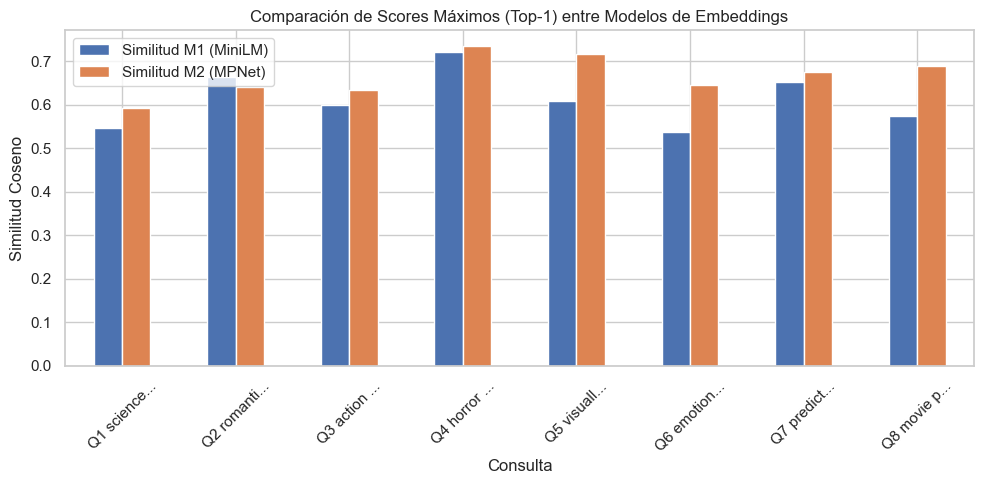

In [ ]:
#  Comparación de scores Top-1 entre Modelo 1 y Modelo 2
comparison_list = []
for q in queries:
    res_m1 = search_system(q, model_1, embeddings_m1, df, k=1).iloc[0]
    res_m2 = search_system(q, model_2, embeddings_m2, df, k=1).iloc[0]
    
    comparison_list.append({
        'Consulta': q[:10] + "...",
        'Similitud M1 (MiniLM)': res_m1['Similitur_Score'] if 'Similitur_Score' in res_m1 else res_m1['Similitud'],
        'Similitud M2 (MPNet)': res_m2['Similitur_Score'] if 'Similitur_Score' in res_m2 else res_m2['Similitud']
    })

comp_df = pd.DataFrame(comparison_list)

# Gráfico de barras comparativo
comp_df.set_index('Consulta').plot(kind='bar', figsize=(10, 5))
plt.title('Comparación de Scores Máximos (Top-1) entre Modelos de Embeddings')
plt.ylabel('Similitud Coseno')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### B. Visualización de Embeddings con PCA


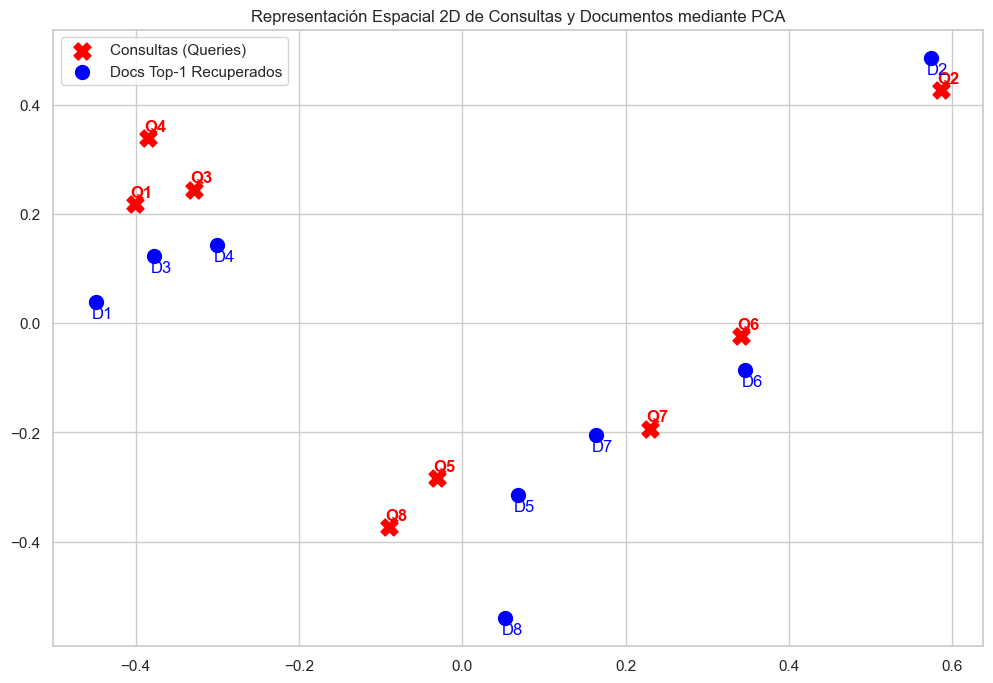

In [25]:
# Celda 11: Visualización espacial con PCA
# Extraer embeddings de las 8 consultas y sus mejores respuestas
queries_clean = [preprocess_text(q) for q in queries]
q_embs = model_2.encode(queries_clean)

# Obtener los índices de los documentos Top-1 reales del Modelo 2
top1_indices = []
for q in queries:
    res = search_system(q, model_2, embeddings_m2, df, k=1)
    top1_indices.append(int(res.iloc[0]['ID documento']))

doc_embs = embeddings_m2[top1_indices]

# Combinar para el PCA
all_embs = np.vstack([q_embs, doc_embs])

pca = PCA(n_components=2)
reduced_embs = pca.fit_transform(all_embs)

# Graficar
plt.figure(figsize=(12, 8))
# Graficar consultas
plt.scatter(reduced_embs[:8, 0], reduced_embs[:8, 1], color='red', marker='X', s=150, label='Consultas (Queries)')
# Graficar documentos recuperados
plt.scatter(reduced_embs[8:, 0], reduced_embs[8:, 1], color='blue', marker='o', s=100, label='Docs Top-1 Recuperados')

# Añadir etiquetas
for i, q in enumerate(queries):
    plt.annotate(f"Q{i+1}", (reduced_embs[i, 0], reduced_embs[i, 1]), textcoords="offset points", xytext=(5,5), ha='center', color='red', weight='bold')
    plt.annotate(f"D{i+1}", (reduced_embs[i+8, 0], reduced_embs[i+8, 1]), textcoords="offset points", xytext=(5,-12), ha='center', color='blue')

plt.title('Representación Espacial 2D de Consultas y Documentos mediante PCA')
plt.legend()
plt.show()